In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier , export_text , plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [3]:
data = {

"Outlook": ["Sunny", "Sunny", "Overcast", "Rain", "Rain", "Rain", "Overcast", "Sunny", "Sunny", "Rain", "Sunny", "Overcast", "Overcast", "Rain"],

 "Temp": ["Hot", "Hot", "Hot", "Mild", "Cool", "Cool", "Cool", "Mild", "Cool", "Mild", "Mild", "Mild", "Hot", "Mild"],

 "Humidity": ["High", "High", "High", "High", "Normal", "Normal", "Normal", "High", "Normal", "Normal", "Normal", "High", "Normal", "High"],

 "Windy": [False, True, False, False, False, True, True, False, False, False, True, True, False, True],

"Play": ["No", "No", "Yes", "Yes", "Yes", "No", "Yes", "No", "Yes", "Yes", "Yes", "Yes", "Yes", "No"]

}
df = pd.DataFrame(data)
df

,Outlook,Temp,Humidity,Windy,Play
0,Sunny,Hot,High,False,No
1,Sunny,Hot,High,True,No
2,Overcast,Hot,High,False,Yes
3,Rain,Mild,High,False,Yes
4,Rain,Cool,Normal,False,Yes
5,Rain,Cool,Normal,True,No
6,Overcast,Cool,Normal,True,Yes
7,Sunny,Mild,High,False,No
8,Sunny,Cool,Normal,False,Yes
9,Rain,Mild,Normal,False,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Outlook   14 non-null     object
 1   Temp      14 non-null     object
 2   Humidity  14 non-null     object
 3   Windy     14 non-null     bool  
 4   Play      14 non-null     object
dtypes: bool(1), object(4)
memory usage: 594.0+ bytes


In [7]:
# for col in df.columns:
#     if df[col].dtype == 'object' or df[col].dtype.name == 'bool': 
#         df[col] = pd.factorize(df[col])[0]

# print(df)


#  or
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype == 'bool':
        df[col] = le.fit_transform(df[col])
print(df)

    Outlook  Temp  Humidity  Windy  Play
0         0     0         0      0     0
1         0     0         0      1     0
2         1     0         0      0     1
3         2     1         0      0     1
4         2     2         1      0     1
5         2     2         1      1     0
6         1     2         1      1     1
7         0     1         0      0     0
8         0     2         1      0     1
9         2     1         1      0     1
10        0     1         1      1     1
11        1     1         0      1     1
12        1     0         1      0     1
13        2     1         0      1     0


In [11]:
X = df[["Outlook","Temp",'Humidity',"Windy"]]
y = df["Play"]

In [12]:
X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size=0.2, random_state=42
)

In [14]:
clf = DecisionTreeClassifier(criterion="entropy",random_state=42)
clf.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [17]:
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test , y_pred)
accuracy

0.6666666666666666

In [20]:
tree_rules = export_text(clf, feature_names=list(X.columns))
tree_rules

'|--- Humidity <= 0.50\n|   |--- Outlook <= 0.50\n|   |   |--- class: 0\n|   |--- Outlook >  0.50\n|   |   |--- Windy <= 0.50\n|   |   |   |--- class: 1\n|   |   |--- Windy >  0.50\n|   |   |   |--- class: 0\n|--- Humidity >  0.50\n|   |--- Outlook <= 1.50\n|   |   |--- class: 1\n|   |--- Outlook >  1.50\n|   |   |--- Windy <= 0.50\n|   |   |   |--- class: 1\n|   |   |--- Windy >  0.50\n|   |   |   |--- class: 0\n'

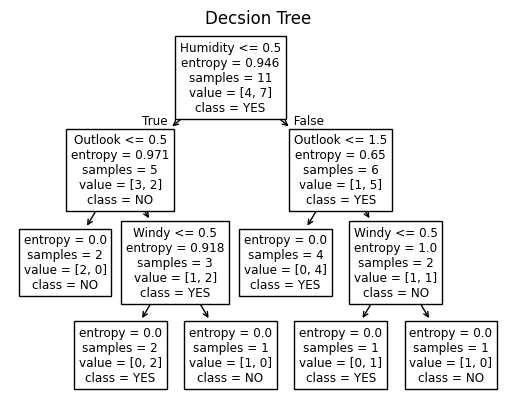

In [23]:
plt.Figure(figsize=(12,8))
plot_tree(clf,feature_names=list(X.columns),
          class_names=["NO","YES"],
          )
plt.title("Decsion Tree")
plt.show()